# Other persistence measures

PLSCAN supports five persistence measures for selecting the minimum cluster
size threshold:

- ``"size"`` persistence
- ``"distance"`` persistence
- ``"density"`` persistence
- ``"size-distance"`` bi-persistence
- ``"size-density"`` bi-persistence

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fast_plscan import PLSCAN
from fast_plscan._api import compute_distance_icicles, compute_density_icicles


plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (2.75, 0.618 * 2.75)

data = np.load("data/clusterable/sources/clusterable_data.npy")

## Size persistence

The default measure (``"size"``) tracks where leaf clusters exist along
minimum cluster size thresholds. The leaf tree visualizes these size intervals
(persistences) for each leaf cluster on the y-axis:

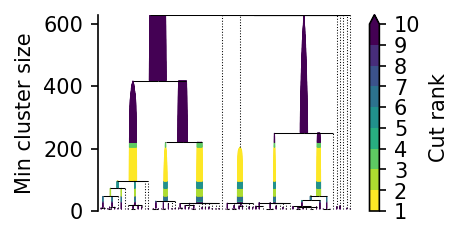

In [2]:
c_size = PLSCAN().fit(data)
c_size.leaf_tree_.plot(leaf_separation=0.1)
plt.show()

The persistence trace sums the size-persistence contributions of all leaf
clusters alive at each minimum cluster size value. Higher total persistence
indicates a more robust clustering at that threshold.

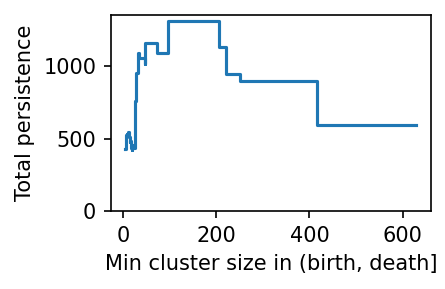

In [3]:
c_size.persistence_trace_.plot()
plt.show()

## Distance persistence

The ``"distance"`` persistence measure is similar, but it quantifies the
distance range over which leaf clusters exist. These ranges are not directly
read from the leaf or condensed tree. A leaf cluster is born at the distance
where its descendants first form a connected component with the cluster's
birth-size points.

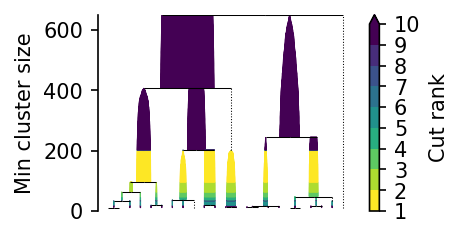

In [4]:
c_dist = PLSCAN(min_samples=10, persistence_measure="distance").fit(data)
c_dist.leaf_tree_.plot(leaf_separation=0.1)
plt.show()

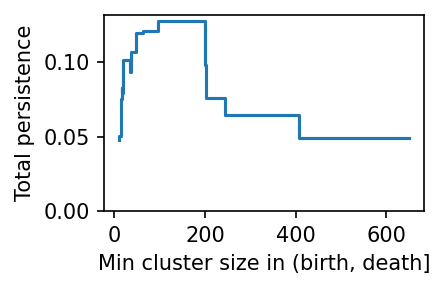

In [5]:
c_dist.persistence_trace_.plot()
plt.show()

## Density persistence

The same distance ranges can also be expressed in density terms via
``exp(-distance)``.

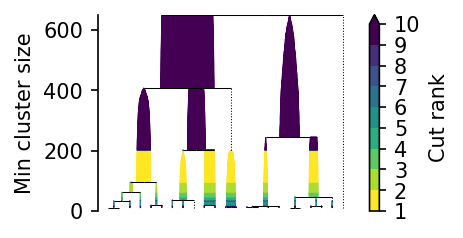

In [6]:
c_dens = PLSCAN(min_samples=10, persistence_measure="density").fit(data)
c_dens.leaf_tree_.plot(leaf_separation=0.1, width="density")
plt.show()

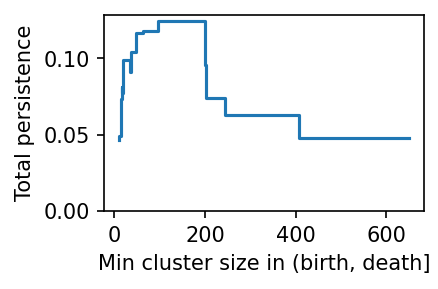

In [7]:
c_dens.persistence_trace_.plot()
plt.show()

## Size--distance bi-persistence

The ``"size-distance"`` bi-persistence measure combines size persistence and
distance persistence. Leaf clusters with low distance persistence receive lower
bi-persistence scores. In this example, clusters below size 100 therefore have
lower relative total persistence and lower cut ranks in the plots below:

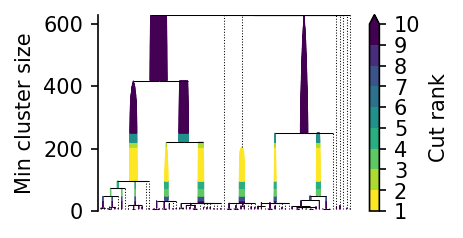

In [8]:
c_sdist = PLSCAN(persistence_measure="size-distance").fit(data)
c_sdist.leaf_tree_.plot(leaf_separation=0.1, width="distance")
plt.show()

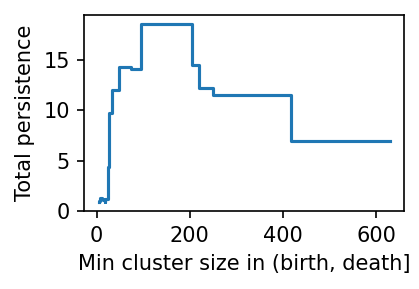

In [9]:
c_sdist.persistence_trace_.plot()
plt.show()

The bi-persistence value can be interpreted as an area in
``(min_cluster_size, distance)`` space where a leaf cluster exists. For
example, leaf cluster 16 occupies the highlighted area:

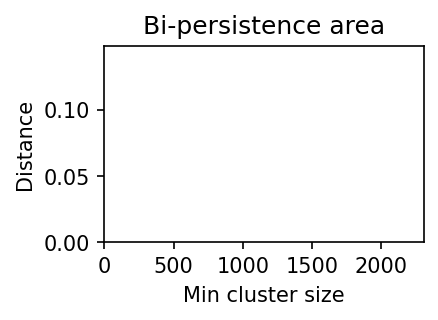

In [10]:
leaf_idx = 15
max_dist = c_sdist._leaf_tree.max_distance[leaf_idx]
size_trace, pers_trace = compute_distance_icicles(
    c_sdist._leaf_tree, c_sdist._condensed_tree, data.shape[0]
)
for size, pers in zip(size_trace[leaf_idx], pers_trace[leaf_idx]):
    plt.plot([size, size], [max_dist - pers, max_dist], "k-")
plt.xlim(0, data.shape[0])
plt.ylim(0, c_sdist._leaf_tree.max_distance[0])
plt.xlabel("Min cluster size")
plt.ylabel("Distance")
plt.title("Bi-persistence area")
plt.show()

## Size--density bi-persistence

The same bi-persistence idea can be expressed in density coordinates.
``hdbscan`` uses ``1 / distance`` as a density transform, while
``fast-plscan`` uses ``exp(-distance)`` to avoid division by zero. Both
transforms map large distances to near-zero density values, so large-distance
segments contribute less to total persistence. (For this dataset, the
difference between ``"size-distance"`` and ``"size-density"`` is small.)

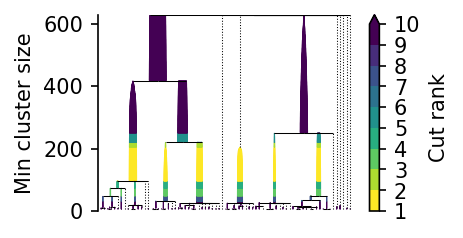

In [11]:
c_sdens = PLSCAN(persistence_measure="size-density").fit(data)
c_sdens.leaf_tree_.plot(leaf_separation=0.1, width="density")
plt.show()

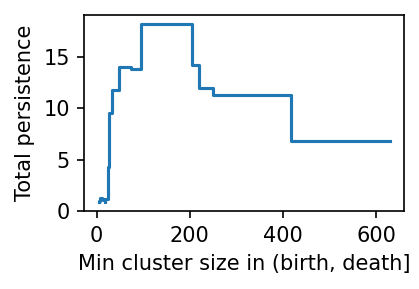

In [12]:
c_sdens.persistence_trace_.plot()
plt.show()

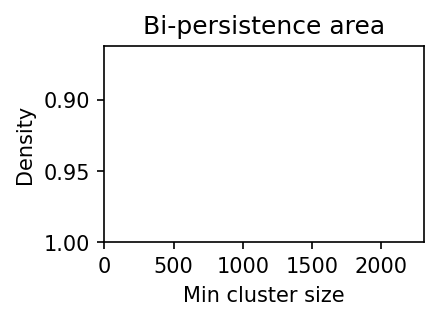

In [13]:
leaf_idx = 15
max_dist = np.exp(-c_sdens._leaf_tree.max_distance[leaf_idx])
size_trace, pers_trace = compute_density_icicles(
    c_sdens._leaf_tree, c_sdens._condensed_tree, data.shape[0]
)
for size, pers in zip(size_trace[leaf_idx], pers_trace[leaf_idx]):
    plt.plot([size, size], [max_dist + pers, max_dist], "k-")
plt.xlim(0, data.shape[0])
plt.ylim(1, np.exp(-c_sdens._leaf_tree.max_distance[0]))
plt.xlabel("Min cluster size")
plt.ylabel("Density")
plt.title("Bi-persistence area")
plt.show()